<a href="https://colab.research.google.com/github/smiritisi-msc26-lgtm/BPTA/blob/main/P3_bpta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

m(Edges)  | Brute Force VC Size | Brute Force Time    | AA VC Size    | AA Time             | Approx. Factor  
-------------------------------------------------------------------------------------------------------------------
20        | 8                   | 0.04756182          | 16            | 0.00003453          | 2.00            
40        | 10                  | 0.26291738          | 18            | 0.00003515          | 1.80            
60        | 13                  | 0.46357807          | 20            | 0.00003167          | 1.54            
80        | 14                  | 0.53206014          | 20            | 0.00004190          | 1.43            
100       | 15                  | 0.62251800          | 20            | 0.00003470          | 1.33            
120       | 16                  | 0.72702340          | 20            | 0.00003488          | 1.25            
140       | 16                  | 0.66323066          | 20            | 0.00003165          | 1.25         

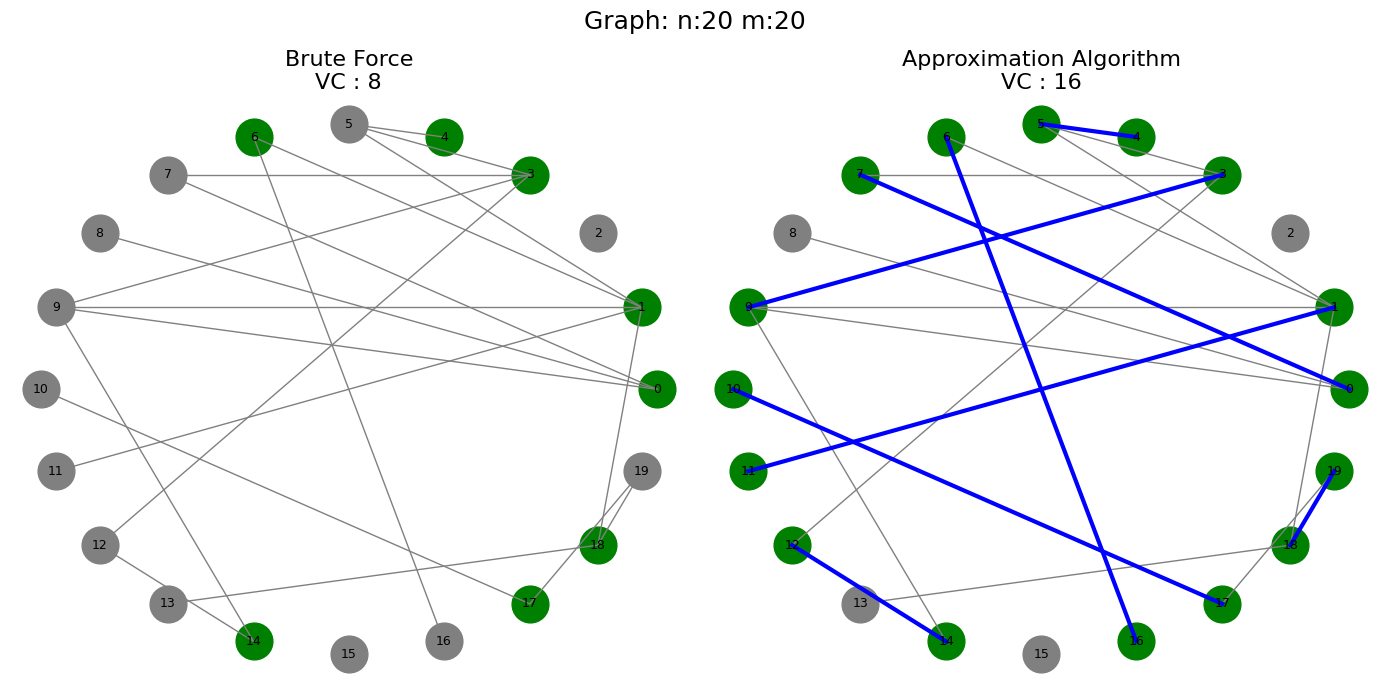

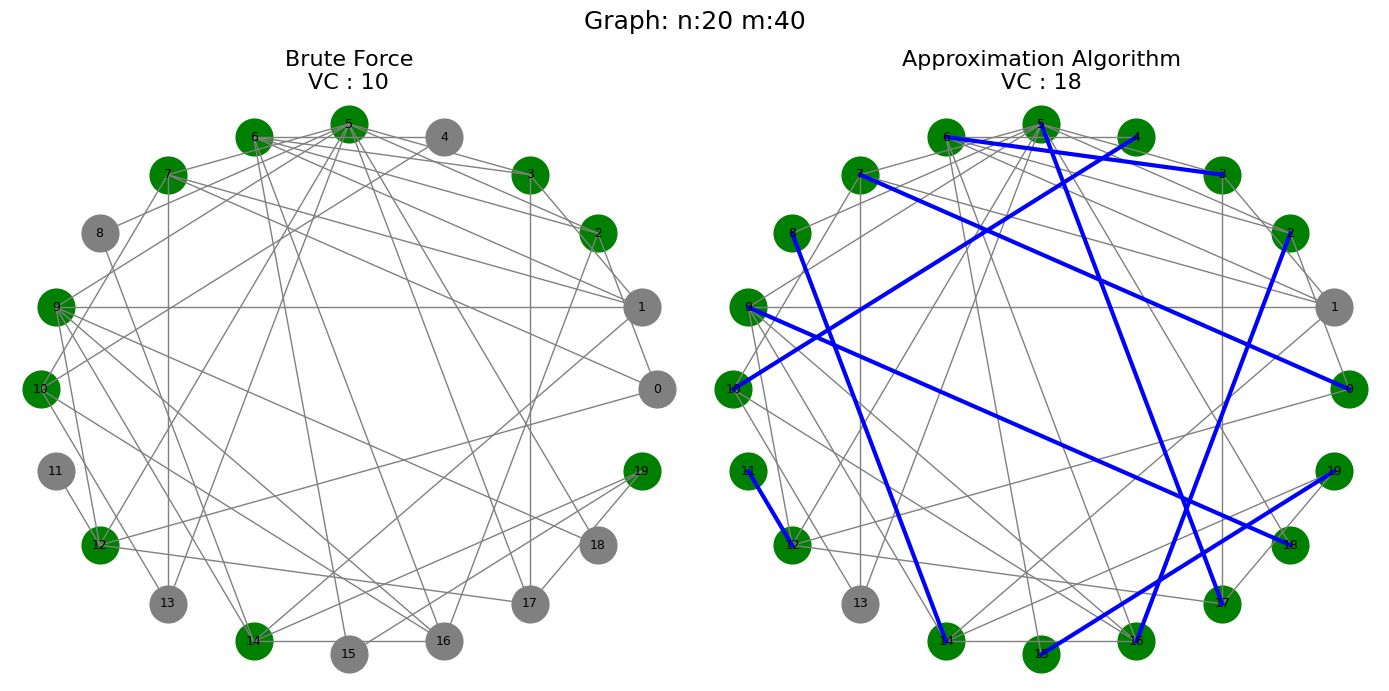

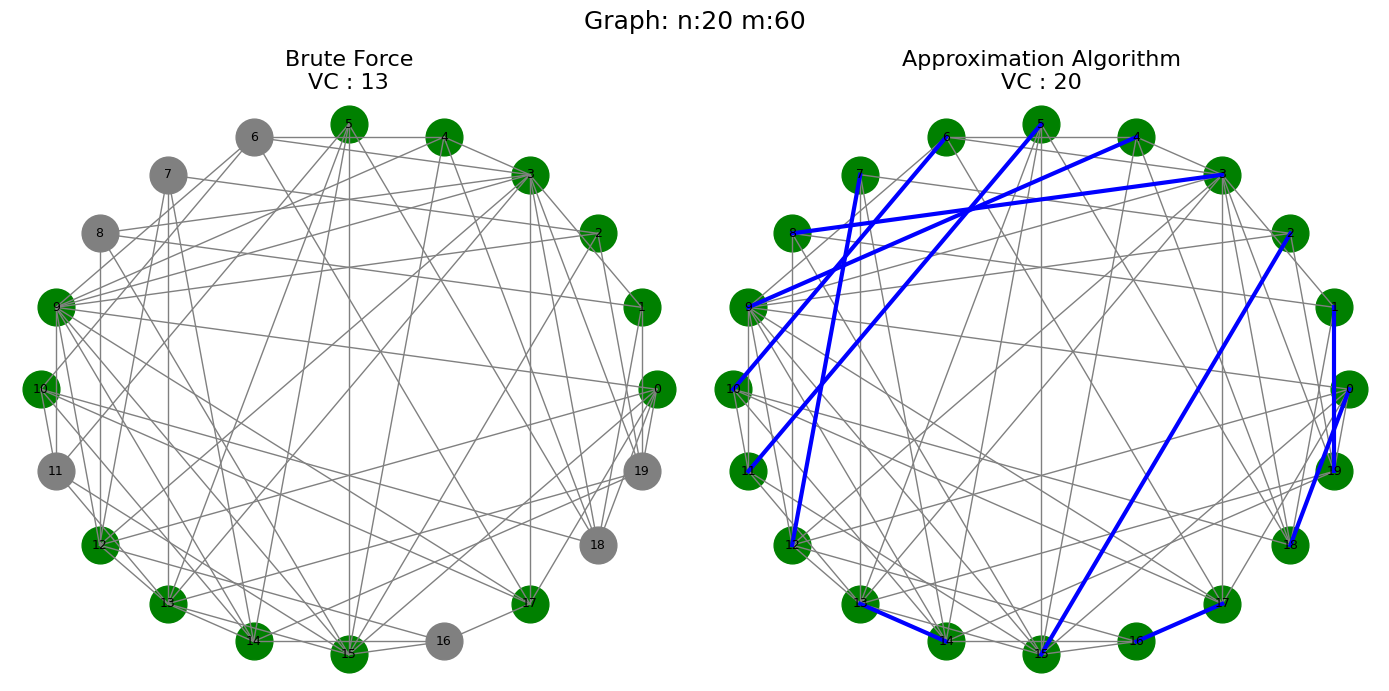

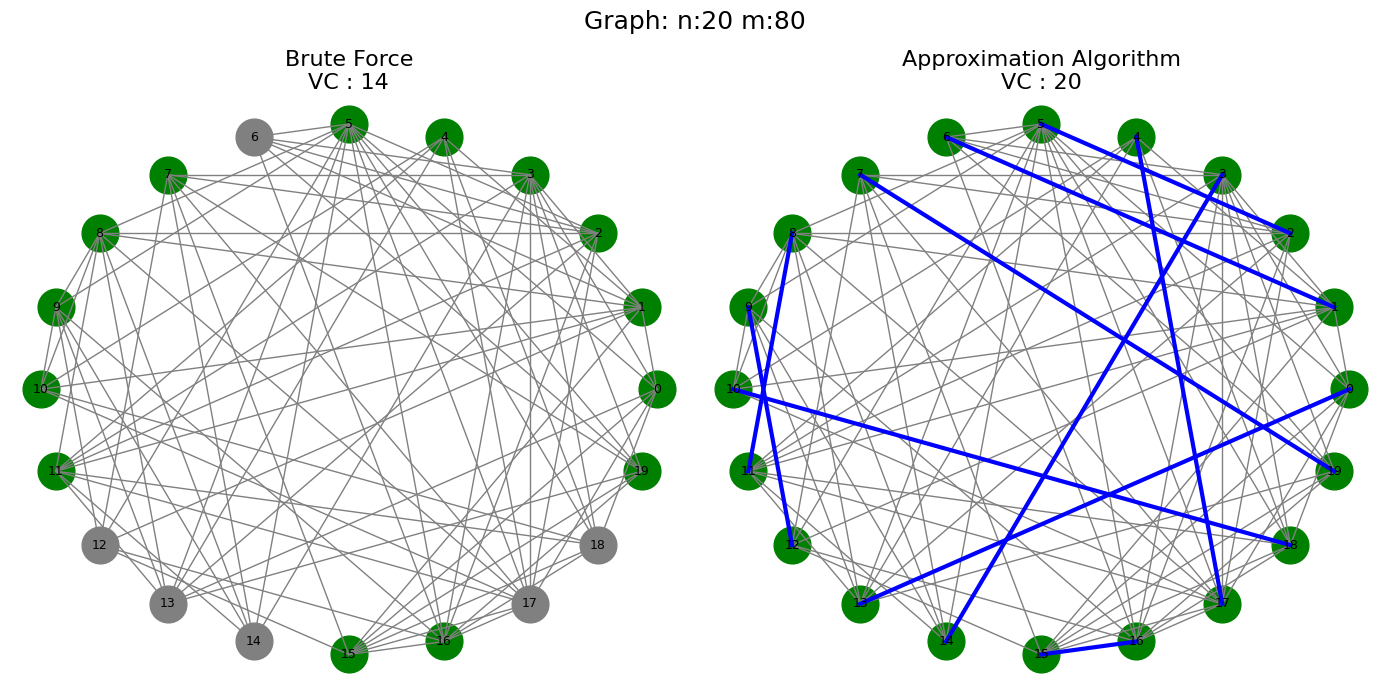

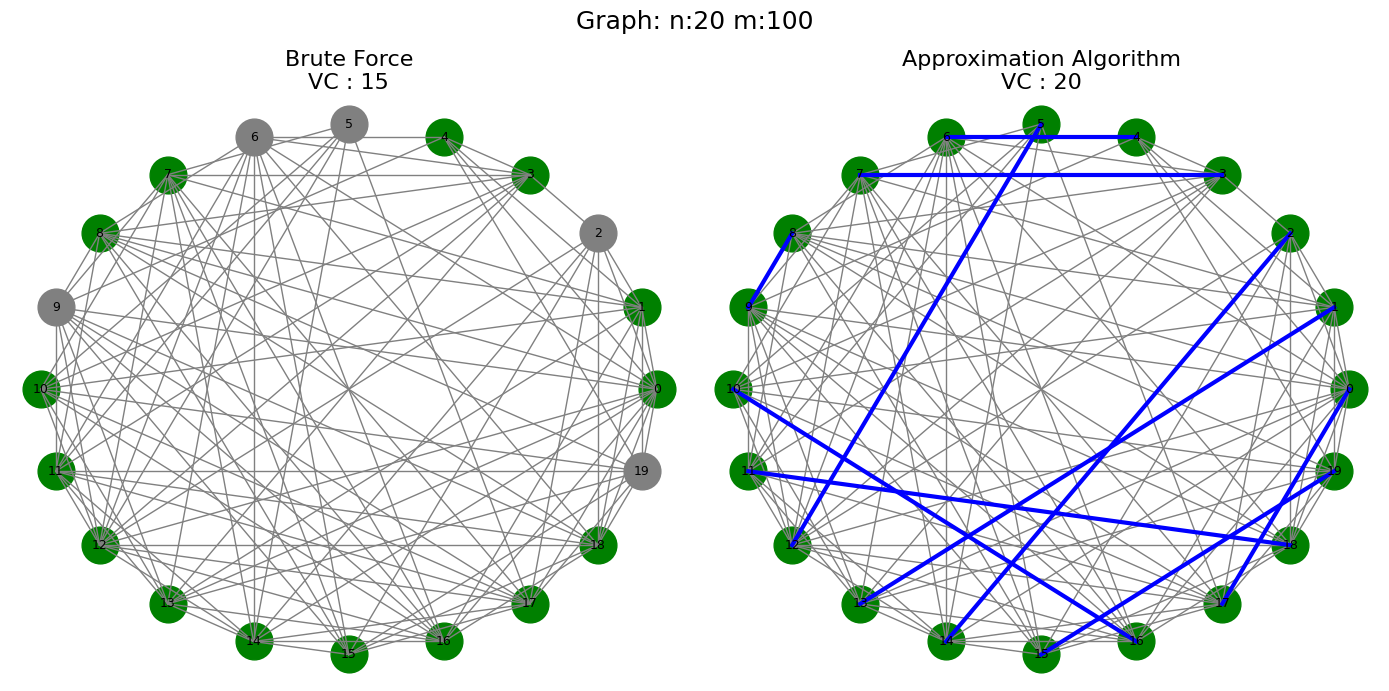

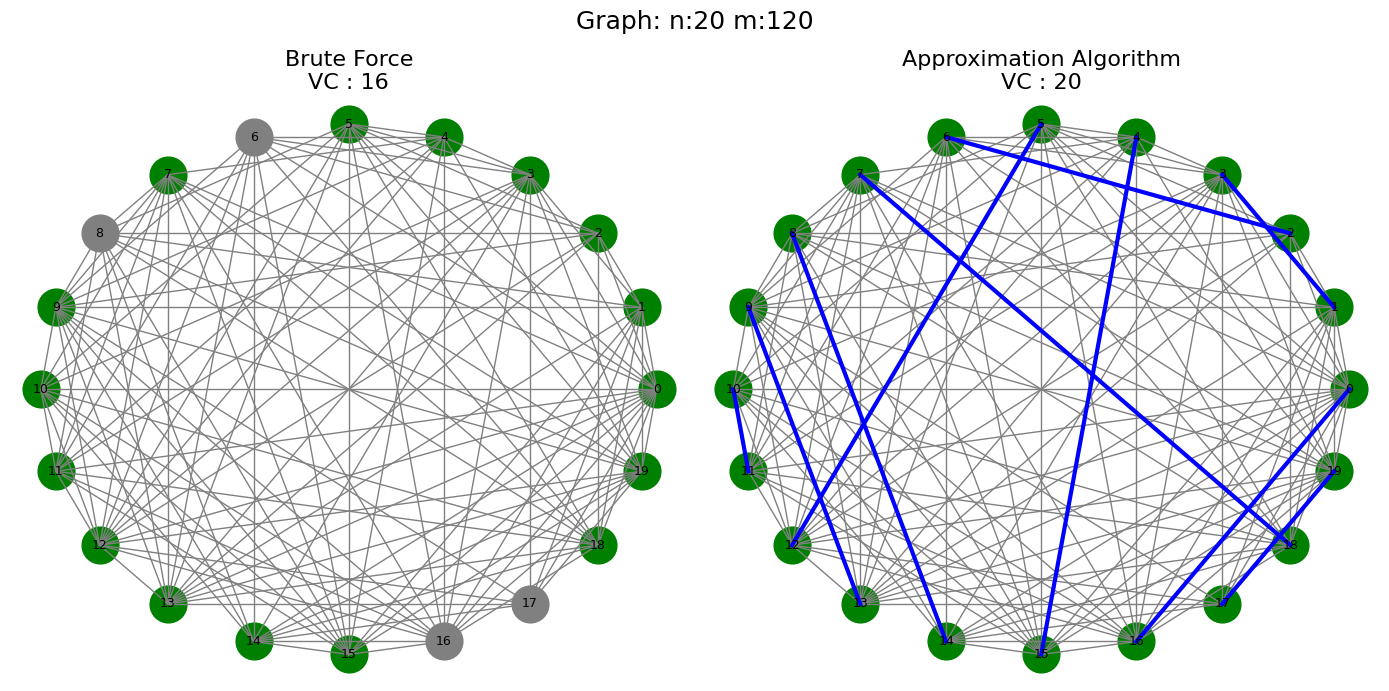

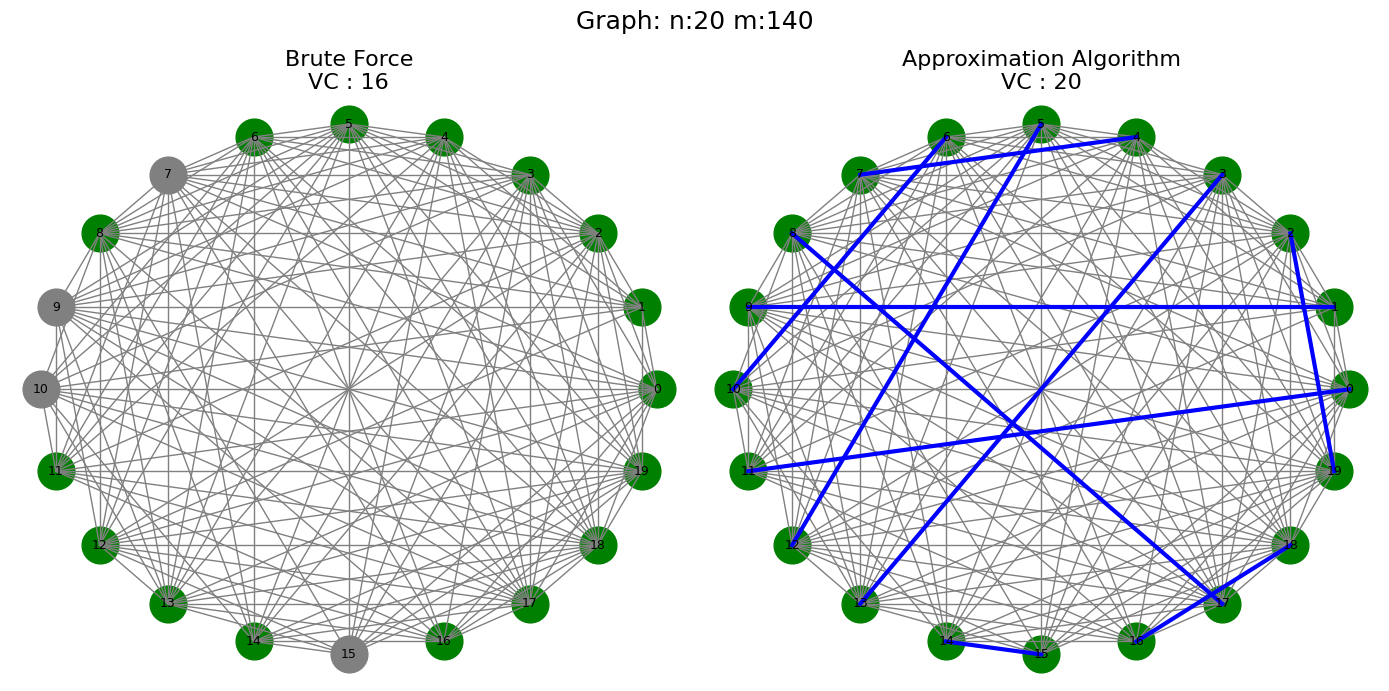

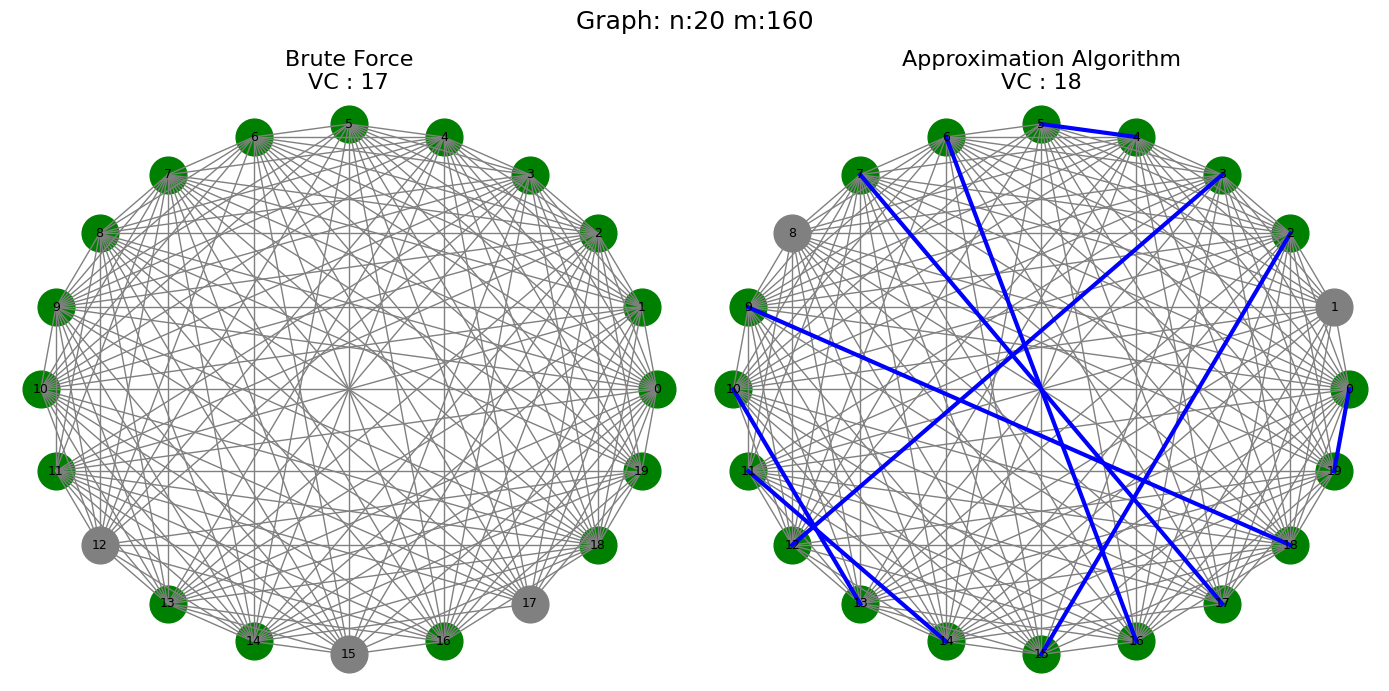

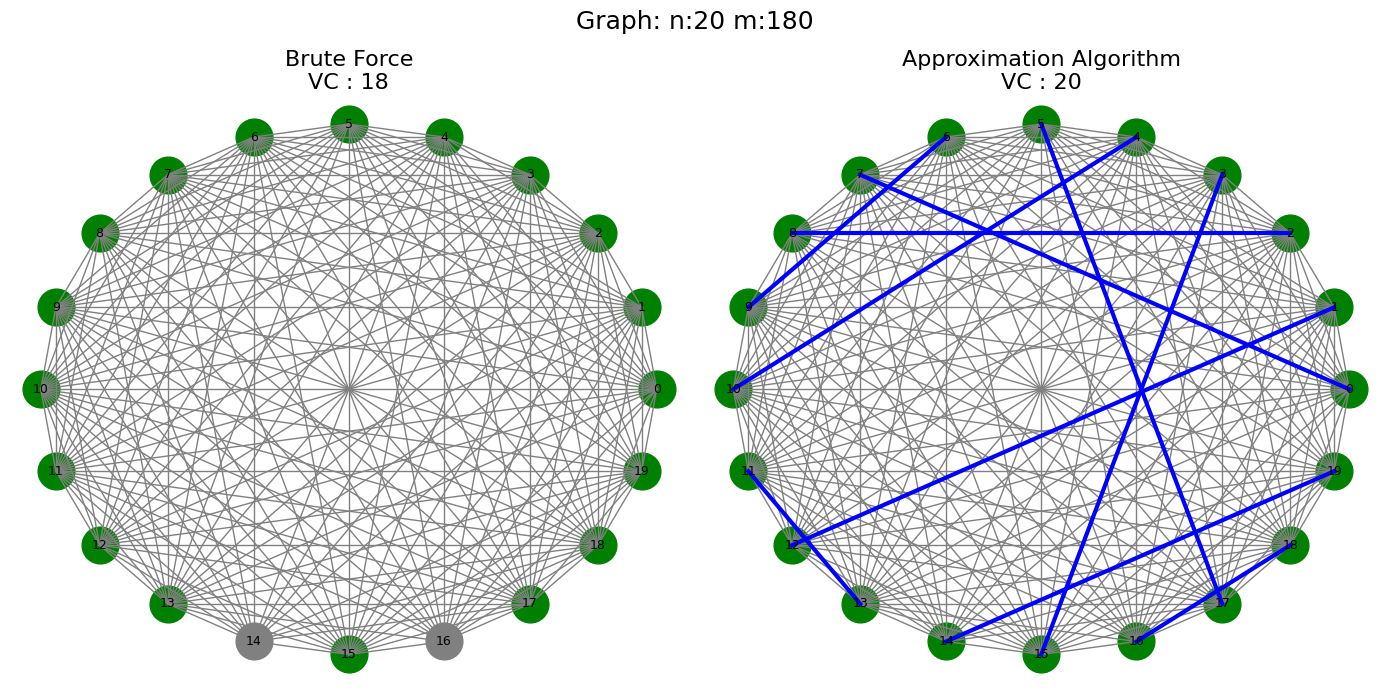

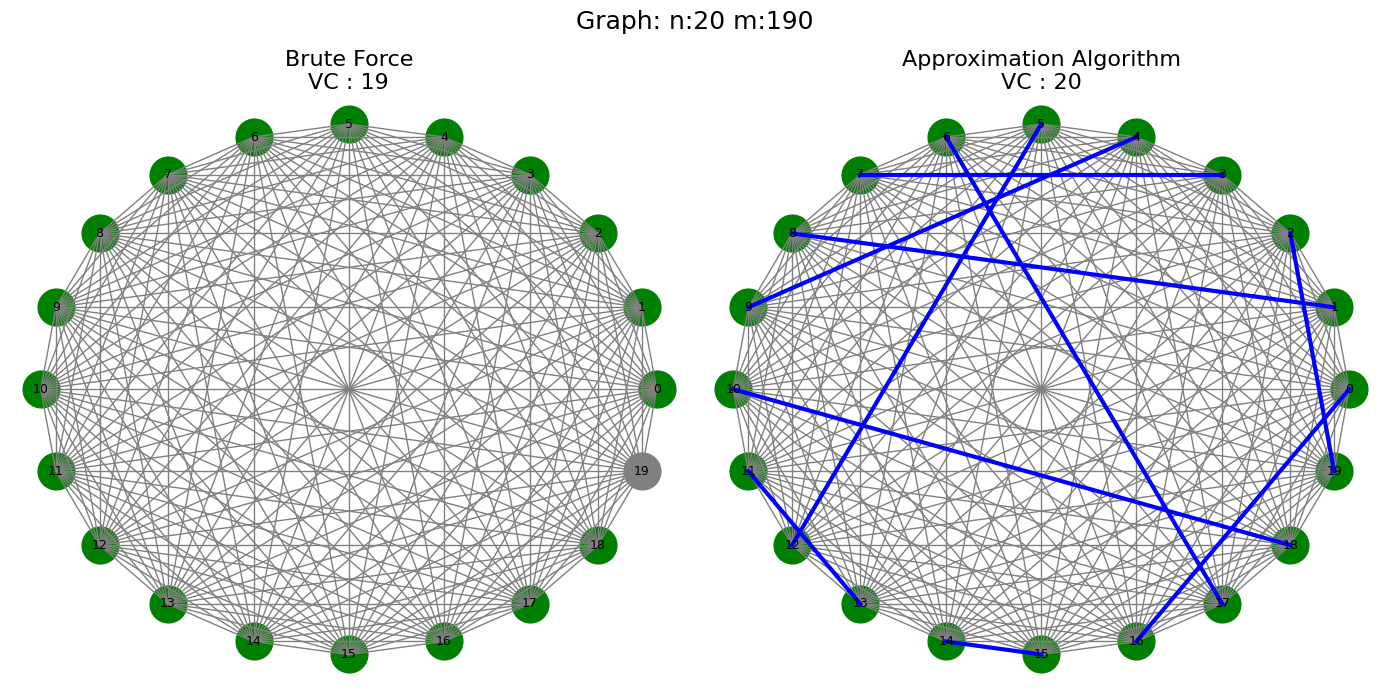

In [ ]:
import time
import random
import itertools
import csv
import math
import matplotlib.pyplot as plt


def is_vertex_cover(edges, subset):
    for u, v in edges:
        if u not in subset and v not in subset:
            return False
    return True


def find_min_vertex_cover(n, edges):
    for k in range(n + 1):
        for subset in itertools.combinations(range(n), k):
            if is_vertex_cover(edges, subset):
                return k, subset


def MaxMatching(edges):
    matching = []
    matchedV = set()

    for u, v in edges:
        if u not in matchedV and v not in matchedV:
            matching.append((u, v))
            matchedV.add(u)
            matchedV.add(v)

    return matching


def Approx_VC(edges):
    matching = MaxMatching(edges)
    vertex_cover = set()

    for u, v in matching:
        vertex_cover.add(u)
        vertex_cover.add(v)

    return matching, tuple(sorted(vertex_cover))


def generate_random_graph(n, m):
    edges = list(itertools.combinations(range(n), 2))
    return random.sample(edges, m)


def plot_graphs(n, edges, brute_cover, AA_VC, matching, m,
                brute_size, AA_size):

    pos = {
        i: (
            5 * math.cos(2 * math.pi * i / n),
            5 * math.sin(2 * math.pi * i / n)
        )
        for i in range(n)
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    for ax, cover, title in [
        (axes[0], brute_cover, "Brute Force"),
        (axes[1], AA_VC, "Approximation Algorithm")
    ]:

        for u, v in edges:
            ax.plot(
                [pos[u][0], pos[v][0]],
                [pos[u][1], pos[v][1]],
                color="gray",
                linewidth=1
            )

        if title == "Approximation Algorithm":
            for u, v in matching:
                ax.plot(
                    [pos[u][0], pos[v][0]],
                    [pos[u][1], pos[v][1]],
                    color="blue",
                    linewidth=3
                )

        for v in range(n):
            ax.scatter(
                *pos[v],
                s=700,
                color="green" if v in cover else "gray"
            )

            ax.text(
                *pos[v],
                str(v),
                ha="center",
                va="center",
                fontsize=9
            )

        ax.set_title(
            title + "\nVC : " +
            str(brute_size if title == "Brute Force" else AA_size),
            fontsize=16
        )

        ax.axis("off")

    fig.suptitle(
        "Graph: n:" + str(n) + " m:" + str(m),
        fontsize=18
    )

    plt.tight_layout()
    plt.show()


n = 20

m_values = [
    20, 40, 60, 80, 100,
    120, 140, 160, 180, 190
]

datasets = []
results = []

random.seed(42)

for m in m_values:

    edges = generate_random_graph(n, m)

    start = time.perf_counter()

    brute_size, brute_cover = find_min_vertex_cover(n, edges)

    brute_time = time.perf_counter() - start

    start = time.perf_counter()

    matching, AA_VC = Approx_VC(edges)

    AA_time = time.perf_counter() - start

    AA_size = len(AA_VC)

    Afactor = AA_size / brute_size

    datasets.append({
        "n": n,
        "m": m,
        "edges": edges
    })

    results.append({
        "n": n,
        "m": m,
        "brute_vertex_cover_size": brute_size,
        "brute_running_time": brute_time,
        "AA_vertex_cover_size": AA_size,
        "AA_running_time": AA_time,
        "approximation_factor": Afactor
    })


print(
    f"{'m(Edges)':<10}| "
    f"{'Brute Force VC Size':<20}| "
    f"{'Brute Force Time':<20}| "
    f"{'AA VC Size':<14}| "
    f"{'AA Time':<20}| "
    f"{'Approx. Factor':<16}"
)

print("-" * 115)

for result in results:
    print(
        f"{result['m']:<10}| "
        f"{result['brute_vertex_cover_size']:<20}| "
        f"{result['brute_running_time']:<20.8f}| "
        f"{result['AA_vertex_cover_size']:<14}| "
        f"{result['AA_running_time']:<20.8f}| "
        f"{result['approximation_factor']:<16.2f}"
    )


with open("P3_vertex_cover_datasets.csv", "w", newline="") as file:

    writer = csv.writer(file)

    writer.writerow([
        "n",
        "m",
        "edges"
    ])

    for dataset in datasets:
        writer.writerow([
            dataset["n"],
            dataset["m"],
            dataset["edges"]
        ])


with open("P3_vertex_cover_results.csv", "w", newline="") as file:

    writer = csv.writer(file)

    writer.writerow([
        "n",
        "m",
        "Brute Force VC Size",
        "Brute Force Time",
        "AA VC Size",
        "AA Time",
        "Approximation Factor"
    ])

    for result in results:
        writer.writerow([
            result["n"],
            result["m"],
            result["brute_vertex_cover_size"],
            result["brute_running_time"],
            result["AA_vertex_cover_size"],
            result["AA_running_time"],
            result["approximation_factor"]
        ])


for dataset, result in zip(datasets, results):

    m = dataset["m"]

    edges = [
        tuple(edge)
        for edge in dataset["edges"]
    ]

    brute_cover = find_min_vertex_cover(n, edges)[1]

    matching, AA_VC = Approx_VC(edges)

    plot_graphs(
        n,
        edges,
        brute_cover,
        AA_VC,
        matching,
        m,
        result["brute_vertex_cover_size"],
        result["AA_vertex_cover_size"]
    )